In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import time

# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms

# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
import os
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES

# -------------------------------------------------------


# -------------------------------
# Load Data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

sys.path contains: /home/ismail/Documents/projects/ml-projects/x42
Number of classes: 7
X_train shape: (20758, 30)
X_test shape: (13840, 30)
y_train shape: (20758,)
y_test labels are not available
Test IDs available: 13840


In [2]:
from src.data_splitter import DataSplitter

# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=42,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy" # folds_xgb.npy?
)

folds = splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True)

# Simple XGBoost

In [7]:

# =========================
# XGBoost Classifier
# =========================
from sklearn.model_selection import RandomizedSearchCV


xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

# =========================
# Hyperparameter grid for tuning
# =========================
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

# =========================
# RandomizedSearchCV
# =========================
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,       # number of random combinations
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42
)

# Fit on training data
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)


# =========================
# Evaluate on full training data
# =========================
y_train_pred_proba = best_model.predict_proba(X_train)[:, 1]
y_train_pred_class = best_model.predict(X_train)

roc_auc = roc_auc_score(y_train, y_train_pred_proba)
logloss = log_loss(y_train, y_train_pred_proba)
accuracy = accuracy_score(y_train, y_train_pred_class)

print("\nTraining final model on full training data...")
print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")

# =========================
# Predict on test data
# =========================
y_pred = best_model.predict(X_test)

# =========================
# Save submission
# =========================
submission = pd.DataFrame({
    'PassengerId': test_ids,  # or the column if you kept PassengerId
    'Survived': y_pred
})

submission.to_csv('submission/xgb_w_RSearchCV_submission.csv', index=False)
print("Submission saved as titanic_submission.csv")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=4, n_estimators=200, reg_alpha=0.01, reg_lambda=3, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=4, n_estimators=200, reg_alpha=0.01, reg_lambda=3, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=4, n_estimators=200, reg_alpha=0.01, reg_lambda=3, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=4, n_estimators=200, reg_alpha=0.01, reg_lambda=3, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.01, max_depth=4, n_estimators=200, reg_alpha=0.01, reg_lambda=3, subsample=0.6; total time=   0.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=5, n_estimators=300, reg_alpha=1, reg_lambda=1, subsample=0.6; total time=   0.0s
[

ValueError: 
All the 250 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
250 fits failed with the following error:
Traceback (most recent call last):
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
  File "/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_II

# Optuna

In [ ]:
import xgboost as xgb
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import gc
from src.data_splitter import DataSplitter
from optuna.integration import XGBoostPruningCallback

# -------------------------------
# XGBoost Objective for Optuna
# -------------------------------
def objective(trial):
    num_classes = len(np.unique(y_train_numeric))
    metric_name = cfg.LIB_PARAMS["xgboost"]["eval_metric"]
    maximize_metric = cfg.MAXIMIZE_METRIC





    # -------------------------------
    # Suggest hyperparameters
    # -------------------------------
    param = {
        "objective": cfg.LIB_PARAMS["xgboost"]["objective"],
        "eval_metric": metric_name,
        "booster": "gbtree",
        "tree_method": "hist",  # "gpu_hist" if using GPU
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 0.5),
        "seed": getattr(cfg, "RANDOM_STATE", 42),








        # 'grow_policy': trial.suggest_categorical('grow_policy', ["depthwise", "lossguide"]),
        # 'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        # 'device': "cuda"
    }

    if num_classes > 2:
        param["num_class"] = num_classes

    # -------------------------------
    # Compute class weights if multiclass
    # -------------------------------
    if cfg.TASK.lower() == "multiclass":
        classes = np.unique(y_train_numeric)
        class_weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        sample_weights = np.array([class_weights[int(c)] for c in y_train_numeric])
    elif cfg.TASK.lower() == "binary":
        sample_weights = None

    # -------------------------------
    # Split folds
    # -------------------------------
    folds = splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True)

    oof_preds = np.zeros((len(X_train), num_classes)) if num_classes > 2 else np.zeros(len(X_train))
    all_fold_evals = []
    fold_results = []
    auc_scores, logloss_scores = [], []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]
        w_tr = sample_weights[train_idx] if sample_weights is not None else None

        dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
        dvalid = xgb.DMatrix(X_val, label=y_val)

        evals_result = {}

        model = xgb.train(
            params=param,
            dtrain=dtrain,
            num_boost_round=cfg.NUM_BOOST_ROUND,
            evals=[(dtrain, "train"), (dvalid, "valid")],
            early_stopping_rounds=getattr(cfg, "EARLY_STOPPING", 100),
            evals_result=evals_result,
            verbose_eval=False,
            callbacks=[XGBoostPruningCallback(trial, f"valid-{metric_name}")]
        )
        # After training, inspect evals_result
        print(evals_result.keys())           # should show: dict_keys(['train', 'valid'])
        print(evals_result['valid'].keys())  # should show metric names, e.g., 'mlogloss' or 'auc'

        # OOF predictions
        pred_val = model.predict(dvalid, iteration_range=(0, model.best_iteration))
        oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Fold evaluation
        # -------------------------------
        if maximize_metric:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val)
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
            auc_scores.append(fold_score)
        else:
            fold_score = log_loss(y_val, pred_val)
            logloss_scores.append(fold_score)

        fold_results.append((n_fold, fold_score, model.best_iteration))
        all_fold_evals.append(evals_result)
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, dtrain, dvalid, X_tr, X_val, y_tr, y_val, pred_val
        gc.collect()


    # -------------------------------
    # Robust best iteration calculation
    # -------------------------------
    fold_iters = []

    for f in all_fold_evals:
        vals = f.get("valid", {}).get(metric_name, [])
        # Convert to numpy array and filter NaNs
        vals = np.array(vals)
        vals = vals[~np.isnan(vals)]  # remove NaNs
        if len(vals) == 0:
            fold_iters.append(0)  # fallback if no valid values
        else:
            fold_iters.append(int(np.argmax(vals) if cfg.MAXIMIZE_METRIC else np.argmin(vals)))

    # Compute mean only from valid fold_iters
    valid_iters = [i for i in fold_iters if not np.isnan(i)]
    best_iter = int(np.round(np.mean(valid_iters))) if valid_iters else 0


    # -------------------------------
    # True OOF score
    # -------------------------------
    if maximize_metric:
        mean_score = roc_auc_score(y_train_numeric, oof_preds) if cfg.TASK.lower() == "binary" \
            else roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        mean_score = log_loss(y_train_numeric, oof_preds)

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if maximize_metric else "LogLoss"
    print("\n" + "*"*50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Best iteration: {iter_:>5d}")
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {np.std([s for _, s, _ in fold_results]):.5f}")
    print("*"*50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_evals", all_fold_evals)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score

✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 20758
Total folds: 5

Fold 0: Train size=16606, Val size=4152
dict_keys(['train', 'valid'])
odict_keys(['mlogloss'])
Fold 1: Train size=16606, Val size=4152
dict_keys(['train', 'valid'])
odict_keys(['mlogloss'])
Fold 2: Train size=16606, Val size=4152
dict_keys(['train', 'valid'])
odict_keys(['mlogloss'])
Fold 3: Train size=16607, Val size=4151
dict_keys(['train', 'valid'])
odict_keys(['mlogloss'])
Fold 4: Train size=16607, Val size=4151
dict_keys(['train', 'valid'])
odict_keys(['mlogloss'])

**************************************************
Fold  1 | LogLoss: 0.44717 | Best iteration:   548
Fold  2 | LogLoss: 0.46562 | Best iteration:   520
Fold  3 | LogLoss: 0.45608 | Best iteration:   268
Fold  4 | LogLoss: 0.45201 | Best iteration:   434
Fold  5 | LogLoss: 0.44466 | Best iteration:   428

Mean LogLoss: 0.45311 ± 0.00739

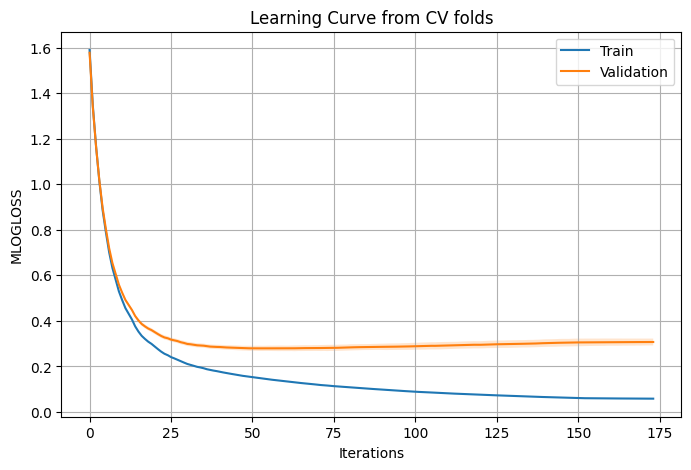


Training final model on full training data...
[0]	train-mlogloss:1.46519
[56]	train-mlogloss:0.13711
---------------- Train Set --------------------
     Metric     Value
0   ROC AUC  0.998077
1  Log Loss  0.137112
2  Accuracy  0.958426
The best mean CV score across all trials: 0.27909729339455397
OOF Accuracy: 0.9035

🔥 BEST STRATEGY: {'mode': 'thresholds', 'thr_0': 0.5398117385336101, 'thr_1': 0.7188853934041055, 'thr_2': 0.6890093475304373, 'thr_3': 0.6872484109583891, 'thr_4': 0.6862015580188162, 'thr_5': 0.8520033888956566, 'thr_6': 0.8384186206320119}
🔥 BEST SEED: 42
🔥 BEST SCORE: 0.9046157552111608
OOF Accuracy after post-processing: 0.9047


4461

In [23]:
from src.optuna_utils import run_optuna
from src.training_utils import train_xgb_final
from src.evaluation_utils import evaluate_model
from src.visualization_utils import plot_feature_importance, plot_learning_curve, shap_summary
from src.experiment_tracker import ExperimentTracker

# -------------------------------
# Run Optuna study
# -------------------------------
start = time.time()

study = run_optuna(objective, cfg)
train_time = time.time() - start

fold_evals = study.best_trial.user_attrs['fold_evals']
plot_learning_curve(fold_evals, metric_name=cfg.LIB_PARAMS["xgboost"]["eval_metric"])
oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final XGBoost model
# -------------------------------
print("\nTraining final model on full training data...")
best_params = study.best_params.copy()
best_params.update({
    'objective': cfg.LIB_PARAMS["xgboost"]["objective"],
    'eval_metric': cfg.LIB_PARAMS["xgboost"]["eval_metric"],
    'verbosity': 0
})
if cfg.TASK.lower() == "multiclass":
    best_params['num_class'] = num_classes

best_iteration = study.best_trial.user_attrs.get("best_iteration", cfg.NUM_BOOST_ROUND)

final_model = train_xgb_final(X_train, y_train_numeric, best_params, best_iteration)



# -------------------------------
# Evaluate on train set
# -------------------------------
print("---------------- Train Set --------------------")

metrics_df, y_pred_train_class = evaluate_model(
    y_train_numeric,
    final_model.predict(xgb.DMatrix(X_train), iteration_range=(0, best_iteration)),
    task=cfg.TASK
)
print(metrics_df)
print("The best mean CV score across all trials:", study.best_value)

if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_accuracy = accuracy_score(y_train_numeric, oof_pred_class)
print(f"OOF Accuracy: {oof_accuracy:.4f}")




# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict(xgb.DMatrix(X_test), iteration_range=(0, best_iteration))
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK=='binary' else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test) if cfg.TASK=='binary' else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)
    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")





# ----------------------------------
# Postprocessing
# ----------------------------------
from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing

# -------------------------------
# Run optimization & show OOF accuracy
# -------------------------------
postprocessing_params = None
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]

    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=200,
        seeds=pp_seeds
    )

    # Apply best post-processing to OOF predictions
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    # y_pred_class_test = apply_postprocessing(pred_test, pp_best_params, task=TASK)
    oof_acc_opt = accuracy_score(y_train_numeric, oof_pred_class_opt)
    print(f"OOF Accuracy after post-processing: {oof_acc_opt:.4f}")

    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL  # or "roc_auc"
    }




# ----------------------------------
# ExperimentTracker
# ----------------------------------

from src.experiment_tracker import ExperimentTracker

tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="lgbm",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params= postprocessing_params,
    use_postprocessing= USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label = int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
    
)


gc.collect()





CV ROC-AUC: 0.9166502331795394
CV Log Loss: 0.34037632043883803
CV Accuracy: 0.8675349946644906


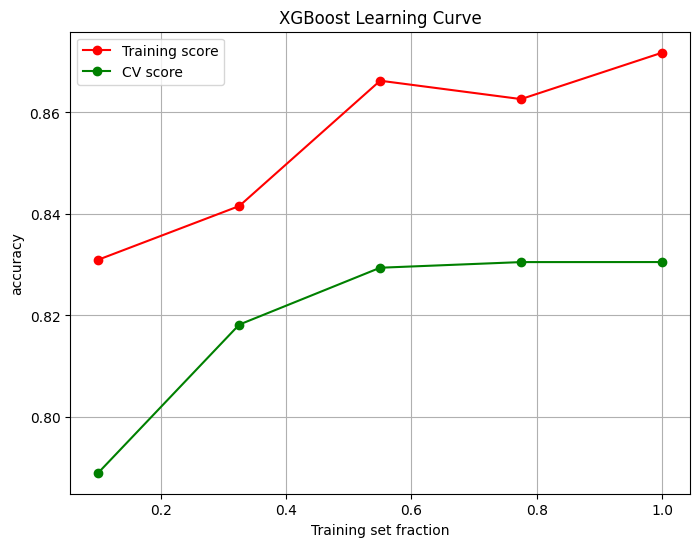

In [ ]:
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import xgboost as xgb
import numpy as np



# -------------------------------
# Learning curve using final_model
# -------------------------------
def plot_learning_curve_xgb_correct(X, y, cv, params, train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy', num_boost_round=None):
    if num_boost_round is None:
        num_boost_round = 100  # default if not provided
    
    train_scores, test_scores = [], []

    for frac in train_sizes:
        fold_train_scores, fold_test_scores = [], []

        for train_idx, test_idx in cv.split(X, y):
            n_train = max(1, int(len(train_idx) * frac))
            train_subset_idx = train_idx[:n_train]

            X_train_subset = X.iloc[train_subset_idx]
            y_train_subset = y.iloc[train_subset_idx]
            X_test_fold = X.iloc[test_idx]
            y_test_fold = y.iloc[test_idx]

            dtrain_subset = xgb.DMatrix(X_train_subset, label=y_train_subset)
            dtest_fold = xgb.DMatrix(X_test_fold, label=y_test_fold)

            # Train booster for this subset
            bst = xgb.train(
                params=params,
                dtrain=dtrain_subset,
                num_boost_round=num_boost_round
            )

            y_train_pred = bst.predict(dtrain_subset)
            y_test_pred = bst.predict(dtest_fold)

            # scoring
            if scoring == 'accuracy':
                fold_train_scores.append(accuracy_score(y_train_subset, (y_train_pred >= 0.5).astype(int)))
                fold_test_scores.append(accuracy_score(y_test_fold, (y_test_pred >= 0.5).astype(int)))
            elif scoring == 'roc_auc':
                fold_train_scores.append(roc_auc_score(y_train_subset, y_train_pred))
                fold_test_scores.append(roc_auc_score(y_test_fold, y_test_pred))
            elif scoring == 'log_loss':
                fold_train_scores.append(-log_loss(y_train_subset, y_train_pred))
                fold_test_scores.append(-log_loss(y_test_fold, y_test_pred))

        train_scores.append(np.mean(fold_train_scores))
        test_scores.append(np.mean(fold_test_scores))

    # Plot
    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_scores, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores, 'o-', color='g', label='CV score')
    plt.title("XGBoost Learning Curve")
    plt.xlabel("Training set fraction")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()


# -------------------------------
# Call learning curve
# -------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

plot_learning_curve_xgb_correct(
    X=X_train,
    y=y_train_numeric,
    cv=skf,
    params=best_params,       # Optuna best hyperparameters
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy',       # or 'roc_auc', 'log_loss'
    num_boost_round=best_iter # use Optuna best iteration
)


In [17]:
import joblib
import numpy as np
import os
import xgboost as xgb
from sklearn.metrics import roc_auc_score, log_loss

folder = "models"
os.makedirs(folder, exist_ok=True)
version = "v2"

# -------------------------------
# Test predictions
# -------------------------------
pred_test = final_model.predict(dtest_full)  # probabilities
roc_auc_test = roc_auc_score(y_test_numeric, pred_test)
auc_str = f"{roc_auc_test:.4f}".replace(".", "p")  # e.g., 0.71 -> 0p71

# -------------------------------
# Save final XGBoost model
# -------------------------------
model_path = os.path.join(folder, f"solo_xgboost_{version}_{auc_str}AUC_optuna.json")
final_model.save_model(model_path)  # XGBoost models are saved as JSON/binary
print(f"Saved model: {model_path}")

# -------------------------------
# Save "OOF" train predictions
# -------------------------------
dtrain_full = xgb.DMatrix(X_train, label=y_train_numeric)
if hasattr(final_model, "predict"):
    oof_train = final_model.predict(dtrain_full)
else:
    oof_train = final_model.predict(dtrain_full)

oof_path = os.path.join(folder, f"solo_xgboost_{version}_{auc_str}AUC_oof_train.npy")
np.save(oof_path, oof_train)
print(f"Saved OOF train predictions: {oof_path}")

# -------------------------------
# Save test predictions
# -------------------------------
pred_path = os.path.join(folder, f"solo_xgboost_{version}_{auc_str}AUC_pred_test.npy")
np.save(pred_path, pred_test)
print(f"Saved test predictions: {pred_path}")


NameError: name 'y_test_numeric' is not defined

# For Stacking

In [31]:
import os
import time
import gc
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.metrics import log_loss, roc_auc_score



# -------------------------------
# Load precomputed folds
# -------------------------------
folds_path = './fold_indices.npy'  # adjust path if needed
folds = np.load(folds_path, allow_pickle=True)
print(f"Loaded {len(folds)} folds")

# -------------------------------
# Prepare OOF and test prediction arrays
# -------------------------------
oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

# -------------------------------
# Optuna objective function for XGBoost
# -------------------------------
def objective(trial):

    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'grow_policy': 'depthwise',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 17),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 30.0),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_loguniform('alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('lambda', 1e-3, 10.0),
        'verbosity': 0,
        'seed': 42
    }

    fold_logloss = []
    best_iters = []

    for train_idx, val_idx in folds:
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[val_idx]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dvalid = xgb.DMatrix(X_val, label=y_val)

        bst = xgb.train(
            params=param,
            dtrain=dtrain,
            num_boost_round=5000,
            evals=[(dvalid, 'valid')],
            early_stopping_rounds=100,
            verbose_eval=False,
            callbacks=[optuna.integration.XGBoostPruningCallback(trial, "valid-logloss")]
        )

        best_iters.append(bst.best_iteration)

        pred_val = bst.predict(dvalid)
        fold_logloss.append(log_loss(y_val, pred_val))

        del X_tr, X_val, y_tr, y_val, bst, pred_val
        gc.collect()

    trial.set_user_attr("best_iteration", int(np.mean(best_iters)))
    return np.mean(fold_logloss)

# -------------------------------
# Run Optuna
# -------------------------------
start = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True))
study.optimize(objective, n_trials=30, timeout=3600)
end = time.time()
print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV logloss:", study.best_value)

best_params = study.best_params
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'verbosity': 0,
    'seed': 42
})

best_iter = study.best_trial.user_attrs.get("best_iteration", 500)

# -------------------------------
# Generate OOF and test predictions for stacking
# -------------------------------
for fold_num, (train_idx, val_idx) in enumerate(folds):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_numeric.iloc[train_idx], y_train_numeric.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    model = xgb.train(
        params=best_params,
        dtrain=dtrain,
        num_boost_round=best_iter
    )

    # OOF predictions
    oof_preds[val_idx] = model.predict(xgb.DMatrix(X_val))

    # Test predictions (average across folds)
    test_preds += model.predict(xgb.DMatrix(X_test)) / len(folds)

    print(f"Fold {fold_num} done.")
    del X_tr, X_val, y_tr, y_val, model
    gc.collect()

# -------------------------------
# Save OOF and test predictions
# -------------------------------
os.makedirs('oof_preds', exist_ok=True)
os.makedirs('test_preds', exist_ok=True)
np.save('oof_preds/xgb_optuna_oof.npy', oof_preds)
np.save('test_preds/xgb_optuna_test.npy', test_preds)
print("OOF and test predictions saved!")

# -------------------------------
# Optional: create submission using test_preds
# -------------------------------
y_pred_class = (test_preds >= 0.5).astype(int)
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": y_pred_class
})
os.makedirs('submission', exist_ok=True)
submission.to_csv("submission/xgb_optuna_submission.csv", index=False)
print("Submission saved!")


[I 2026-02-09 20:34:48,855] A new study created in memory with name: no-name-717d47f2-d6b6-462b-b1ae-85f667937206


Loaded 5 folds


[I 2026-02-09 20:34:55,638] Trial 0 finished with value: 0.41332480564533736 and parameters: {'learning_rate': 0.27105111592556397, 'max_depth': 14, 'min_child_weight': 7.064862138644017, 'subsample': 0.566877705065572, 'colsample_bytree': 0.8302396869474775, 'colsample_bylevel': 0.6331732077128311, 'gamma': 3.107922900277526, 'alpha': 0.018711690991518672, 'lambda': 0.017741439908526755}. Best is trial 0 with value: 0.41332480564533736.
[I 2026-02-09 20:34:56,510] Trial 1 finished with value: 0.4256478506041728 and parameters: {'learning_rate': 0.2184476776146568, 'max_depth': 11, 'min_child_weight': 11.533603194796738, 'subsample': 0.6883661226925273, 'colsample_bytree': 0.46763183022296456, 'colsample_bylevel': 0.7641532950362563, 'gamma': 0.20283452633665877, 'alpha': 0.011056226301838657, 'lambda': 0.12529721451037149}. Best is trial 0 with value: 0.41332480564533736.
[I 2026-02-09 20:34:58,902] Trial 2 finished with value: 0.4354447674155926 and parameters: {'learning_rate': 0.03

Optuna finished in 24.70 seconds
Best params: {'learning_rate': 0.2630302110699656, 'max_depth': 11, 'min_child_weight': 5.217107154413414, 'subsample': 0.4680891466876509, 'colsample_bytree': 0.9191132298960469, 'colsample_bylevel': 0.5232041674132576, 'gamma': 2.5876466932366458, 'alpha': 0.16753190386369746, 'lambda': 0.001554828187123906}
Best CV logloss: 0.4118024323218704
Fold 0 done.
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
OOF and test predictions saved!
Submission saved!


In [6]:
import optuna.visualization as vis



# Slice plot for individual params
vis.plot_slice(study)


In [7]:
vis.plot_param_importances(study)


In [8]:
# Parallel coordinate plot of top trials
vis.plot_parallel_coordinate(study)

In [9]:
vis.plot_contour(study)

[W 2026-01-28 17:57:08,571] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,573] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,574] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,575] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,575] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,576] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,576] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,577] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,577] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,578] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,578] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,578] Param random_state unique value length is less than 2.
[W 2

In [10]:
vis.plot_optimization_history(study)

In [11]:
vis.plot_intermediate_values(study)

In [12]:
import shap
import numpy as np
X_shap = X_train.sample(1000, random_state=42)  # reduce if slow
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    class_names=[f"Class {i}" for i in range(len(shap_values))]
)

ValueError: could not convert string to float: '[6.2333894E-1]'